# lcbinint / VBM limb-darkened light curve

This notebook uses the public `LightCurve` callable API with a parameter dictionary.  The example focuses on a limb-darkened finite-source light curve, where the inverse-ray implementation is expected to be faster than VBM while staying within the requested tolerance.


In [1]:
from dataclasses import dataclass
import collections
from pathlib import Path
import statistics
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "build").exists()),
    Path.cwd(),
)
build_path = repo_root / "build"
if build_path.exists():
    sys.path.insert(0, str(build_path))

import lcbinint

try:
    import VBMicrolensing
except ImportError:
    VBMicrolensing = None


In [2]:
@dataclass(frozen=True)
class Case:
    s: float = 0.95
    q: float = 1.0e-2
    t0: float = 0.0
    tE: float = 1.0
    u0: float = -1.0e-3
    alpha: float = 0.5
    rho: float = 5.0e-3
    t_min: float = -0.8
    t_max: float = 0.8
    n_times: int = 400


case = Case()
times = np.linspace(case.t_min, case.t_max, case.n_times)
params = {
    "t0": case.t0,
    "tE": case.tE,
    "u0": case.u0,
    "alpha": case.alpha,
    "s": case.s,
    "q": case.q,
    "rho": case.rho,
}

options = lcbinint.Options(coordinates="vbm", source_bins=50, max_source_bins=400, reltol=1.0e-3)
limb_darkening = lcbinint.LimbDarkening.linear(0.5)
lightcurve = lcbinint.LightCurve(
    lens="binary_lens",
    options=options,
    limb_darkening=limb_darkening,
)


In [3]:
def timed_median(func, repeats=5):
    samples = []
    value = None
    for _ in range(repeats):
        start = time.perf_counter()
        value = func()
        samples.append(time.perf_counter() - start)
    return value, statistics.median(samples), samples


def evaluate_lcbinint():
    lightcurve(times, params)  # warm up internal caches
    values, elapsed, samples = timed_median(lambda: np.asarray(lightcurve(times, params)))
    info = lightcurve.info(times.tolist(), params)
    return values, elapsed, samples, info


def evaluate_vbm():
    if VBMicrolensing is None:
        return np.full_like(times, np.nan), np.nan, []

    vbm = VBMicrolensing.VBMicrolensing()
    vbm.Tol = 1.0e-3
    vbm.a1 = 0.5
    vbm.a2 = 0.0
    vbm_params = [
        np.log(case.s),
        np.log(case.q),
        case.u0,
        case.alpha,
        np.log(case.rho),
        np.log(case.tE),
        case.t0,
    ]
    times_list = times.tolist()
    vbm.BinaryLightCurve(vbm_params, times_list)  # warm up
    values, elapsed, samples = timed_median(
        lambda: np.asarray(vbm.BinaryLightCurve(vbm_params, times_list)[0])
    )
    return values, elapsed, samples


def relative_error(reference, values):
    return np.abs(values - reference) / np.maximum(np.abs(reference), 1.0e-12)


lc_values, lc_elapsed, lc_samples, lc_info = evaluate_lcbinint()
vbm_values, vbm_elapsed, vbm_samples = evaluate_vbm()

lc_ms = 1.0e3 * lc_elapsed / times.size
vbm_ms = 1.0e3 * vbm_elapsed / times.size
rel = relative_error(vbm_values, lc_values)
method_mix = collections.Counter(lc_info.finite_source_method_names)

print("limb-darkened finite-source light curve")
print(f"lcbinint: {lc_ms:.4f} ms/point")
if np.isfinite(vbm_ms):
    print(f"VBM     : {vbm_ms:.4f} ms/point")
    print(f"speedup : {vbm_ms / lc_ms:.2f}x")
    print(
        "relative error vs VBM: "
        f"max={np.nanmax(rel):.3e}, p99={np.nanpercentile(rel, 99):.3e}, "
        f"median={np.nanmedian(rel):.3e}, rms={np.sqrt(np.nanmean(rel * rel)):.3e}"
    )
print(f"method mix: {dict(method_mix)}")
print(f"converged: {sum(lc_info.finite_source_converged)}/{times.size}")


limb-darkened finite-source light curve
lcbinint: 0.4719 ms/point
VBM     : 0.9256 ms/point
speedup : 1.96x
relative error vs VBM: max=3.635e-04, p99=2.990e-04, median=6.917e-16, rms=6.598e-05
method mix: {'point_source': 297, 'hexadecapole': 45, 'inverse_ray_cartesian': 56, 'inverse_ray_polar': 2}
converged: 344/400


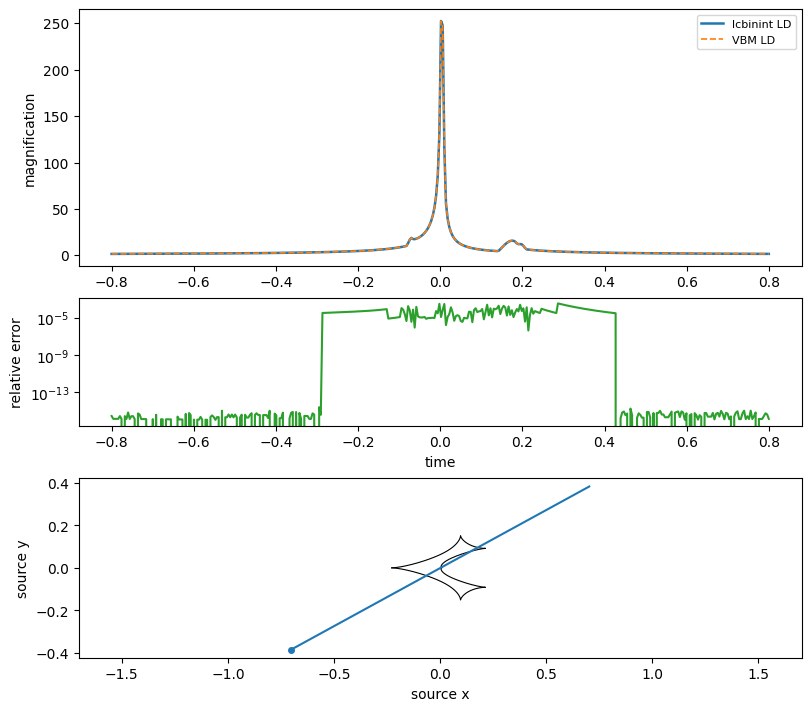

In [4]:
trajectory = lightcurve.source_trajectory(
    times.tolist(),
    t0=params["t0"],
    tE=params["tE"],
    u0=params["u0"],
    alpha=params["alpha"],
    s=params["s"],
    q=params["q"],
)
caustics = lightcurve.caustics(s=case.s, q=case.q, n_points=900)

fig, (ax_mag, ax_res, ax_geo) = plt.subplots(
    3,
    1,
    figsize=(8, 7),
    gridspec_kw={"height_ratios": [2.0, 1.0, 1.4]},
    constrained_layout=True,
)

ax_mag.plot(times, lc_values, label="lcbinint LD", lw=1.8)
if np.all(np.isfinite(vbm_values)):
    ax_mag.plot(times, vbm_values, "--", label="VBM LD", lw=1.2)
ax_mag.set_ylabel("magnification")
ax_mag.legend(fontsize=8)

if np.all(np.isfinite(vbm_values)):
    ax_res.semilogy(times, rel, color="tab:green")
else:
    ax_res.text(0.5, 0.5, "VBM is not installed", ha="center", va="center")
ax_res.set_ylabel("relative error")
ax_res.set_xlabel("time")

for xs, ys in zip(caustics.x, caustics.y):
    ax_geo.plot(xs, ys, color="black", lw=0.8)
ax_geo.plot(trajectory.x, trajectory.y, color="tab:blue", lw=1.5)
ax_geo.scatter([trajectory.x[0]], [trajectory.y[0]], s=16, color="tab:blue")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set_xlabel("source x")
ax_geo.set_ylabel("source y")
plt.show()
